In [ ]:
# importing necessary libraries
import pandas as pd # manupuler des tableaux de données (dataframe)
import matplotlib.pyplot as plt # librairie de visualisation de base (bas niveau).
import seaborn as sns # couche haut niveau au-dessus de matplotlib pour des graphiques statistiques.
import numpy as np # calcul numérique performant
%matplotlib inline



In [ ]:
df = pd.read_csv('phishing_detection.csv')

In [ ]:
df.head()

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [ ]:
df.shape

(11055, 32)

In [ ]:
df.columns

Index(['id', 'having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
       'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length',
       'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor',
       'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL',
       'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe',
       'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank',
       'Google_Index', 'Links_pointing_to_page', 'Statistical_report',
       'Result'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   id                           11055 non-null  int64
 1   having_IP_Address            11055 non-null  int64
 2   URL_Length                   11055 non-null  int64
 3   Shortining_Service           11055 non-null  int64
 4   having_At_Symbol             11055 non-null  int64
 5   double_slash_redirecting     11055 non-null  int64
 6   Prefix_Suffix                11055 non-null  int64
 7   having_Sub_Domain            11055 non-null  int64
 8   SSLfinal_State               11055 non-null  int64
 9   Domain_registeration_length  11055 non-null  int64
 10  Favicon                      11055 non-null  int64
 11  port                         11055 non-null  int64
 12  HTTPS_token                  11055 non-null  int64
 13  Request_URL                  11055 non-null  i

In [ ]:
# no null values
df.isnull().sum()

,0
id,0
having_IP_Address,0
URL_Length,0
Shortining_Service,0
having_At_Symbol,0
double_slash_redirecting,0
Prefix_Suffix,0
having_Sub_Domain,0
SSLfinal_State,0
Domain_registeration_length,0


<Axes: xlabel='Result', ylabel='count'>

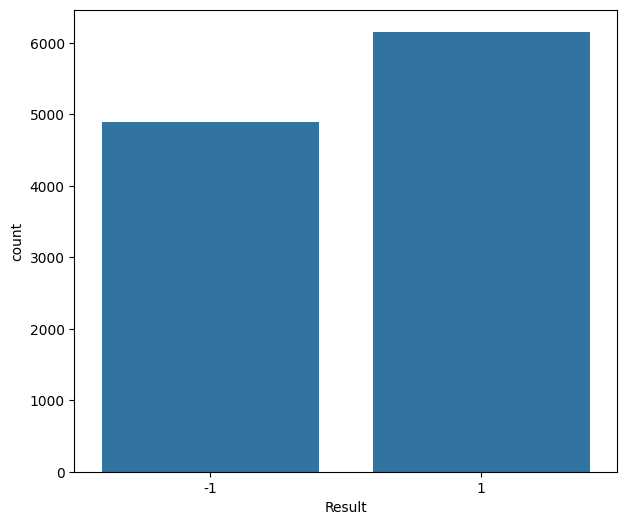

In [ ]:
plt.figure(figsize=(7,6))
# count numbers of class records for 'Result' target attribute
sns.countplot(x='Result', data = df)

In [ ]:
df['Result'].value_counts()

,count
Result,
1,6157
-1,4898


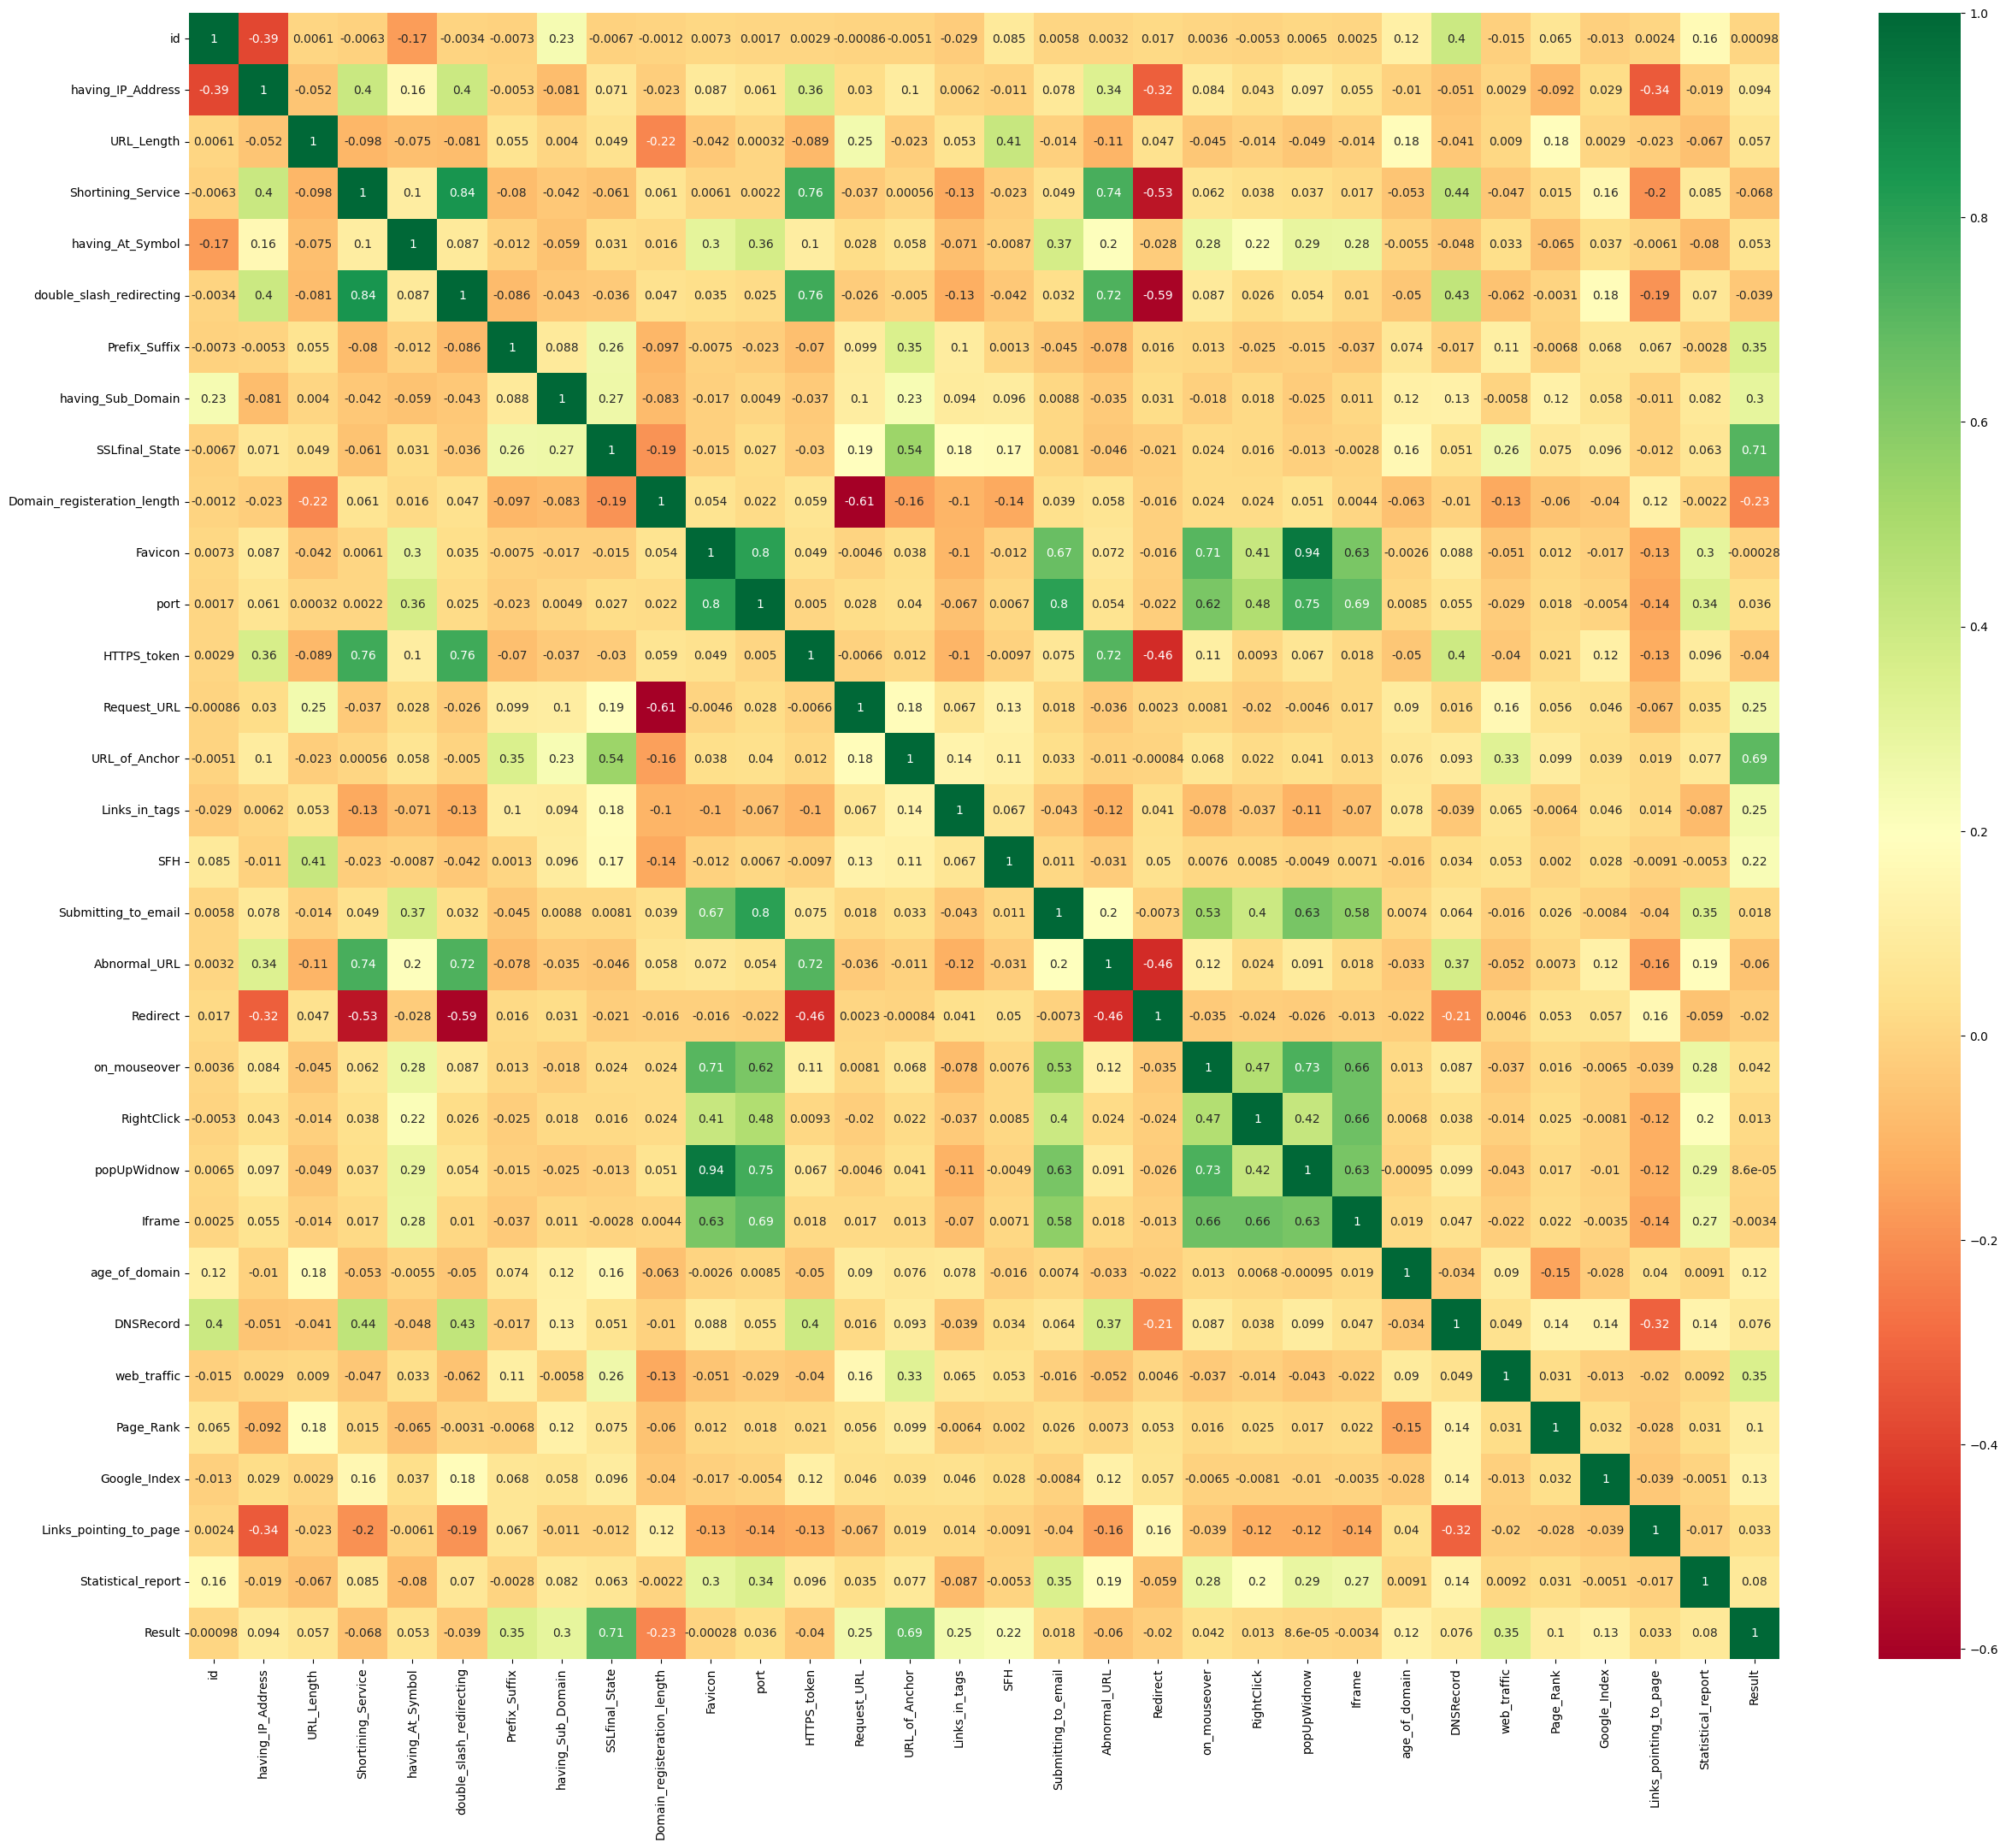

In [ ]:
# creating correlation matrix on the features
corrmat = df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(30, 25))
# representation of correalation matrix through heatmap
g = sns.heatmap(df[top_corr_features].corr(), annot = True, cmap = "RdYlGn")

In [ ]:
col_corr = set() # Set of all the names of deleted columns
def correlation(dataset, threshold):
  corr_matrix = dataset.corr()
  for i in range(len(corr_matrix.columns)):
      for j in range(i):
          if (abs(corr_matrix.iloc[i, j]) >= threshold) and (corr_matrix.columns[j] not in col_corr):
              colname = corr_matrix.columns[i] # getting the name of column
              col_corr.add(colname)

In [ ]:
# remove multicollinear column with collinearity greater than 0.85
correlation(df, 0.85)
col_corr

{'popUpWidnow'}

In [ ]:
# identifying weakly correlated features with target attribute
weak_col_corr = set()
def weakcorrelation(dataset, threshold):
  corr_matrix = dataset.corr()
  idx = 0
  for feature in corr_matrix['Result']:
    if(feature < threshold):
      weak_col_corr.add(corr_matrix.columns[idx])
    idx += 1

 # dropping features with correlation less than 0.01
weakcorrelation(df, 0.01)
print(weak_col_corr)

{'popUpWidnow', 'Redirect', 'id', 'HTTPS_token', 'Shortining_Service', 'double_slash_redirecting', 'Domain_registeration_length', 'Iframe', 'Abnormal_URL', 'Favicon'}


In [ ]:
# gathering all columns that were identified to be deleted
del_col = col_corr.union(weak_col_corr)
del_col

{'Abnormal_URL',
 'Domain_registeration_length',
 'Favicon',
 'HTTPS_token',
 'Iframe',
 'Redirect',
 'Shortining_Service',
 'double_slash_redirecting',
 'id',
 'popUpWidnow'}

In [ ]:
# dropping columns permanantly
df.drop(del_col, axis = 1, inplace = True)

In [ ]:
df.isnull().sum()

,0
having_IP_Address,0
URL_Length,0
having_At_Symbol,0
Prefix_Suffix,0
having_Sub_Domain,0
SSLfinal_State,0
port,0
Request_URL,0
URL_of_Anchor,0
Links_in_tags,0


In [ ]:
# Load libraries
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation

In [ ]:
# input attribute and target attribute
X = df.iloc[: , :-1]
y = df.iloc[:, -1:]

In [ ]:
y

,Result
0,-1
1,-1
2,-1
3,-1
4,1
...,...
11050,1
11051,-1
11052,-1
11053,-1


In [ ]:
# train test split with test size as 0.25
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

In [ ]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

In [ ]:
clf.score(X_train, y_train)

0.9879387287420094

In [ ]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9569464544138929


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.94      0.96      0.95      1236
           1       0.97      0.95      0.96      1528

    accuracy                           0.96      2764
   macro avg       0.96      0.96      0.96      2764
weighted avg       0.96      0.96      0.96      2764



In [ ]:
# the confusion matrix for our model
confusion_matrix(y_test, y_pred)

array([[1191,   45],
       [  74, 1454]])

<Axes: >

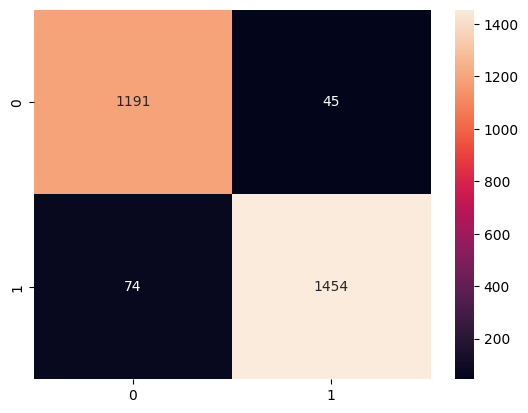

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt='0.0f')

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100)
# fittin the model
rfc.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

In [ ]:
# prediction on validation dataset
y_pred = rfc.predict(X_test)

In [ ]:
# prediction on training dataset
y_pred_train = rfc.predict(X_train)

In [ ]:
from sklearn import metrics
print("Train ACCURACY OF THE MODEL: ", metrics.accuracy_score(y_train, y_pred_train))

Train ACCURACY OF THE MODEL:  0.9879387287420094


In [ ]:
from sklearn import metrics
print("ACCURACY OF THE MODEL: ", metrics.accuracy_score(y_test, y_pred))

ACCURACY OF THE MODEL:  0.9670767004341534


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.97      0.96      0.96      1236
           1       0.97      0.98      0.97      1528

    accuracy                           0.97      2764
   macro avg       0.97      0.97      0.97      2764
weighted avg       0.97      0.97      0.97      2764



In [ ]:
confusion_matrix(y_test, y_pred)

array([[1183,   53],
       [  38, 1490]])

<Axes: >

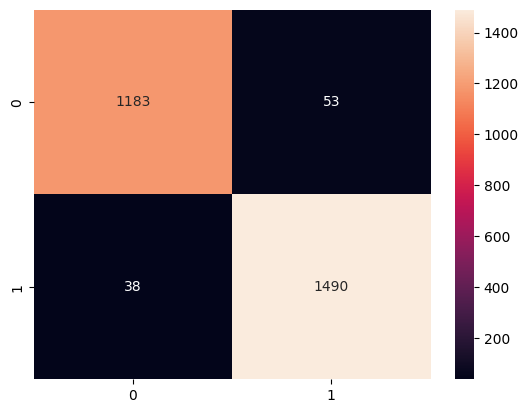

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt='0.0f')

In [ ]:
from sklearn.svm import SVC
# Building a Support Vector Machine on train data
svc_model = SVC(C= .1, gamma= 1, kernel='sigmoid', random_state=42)

In [ ]:
svc_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=0.1, gamma=1, kernel='sigmoid', random_state=42)

In [ ]:
prediction = svc_model .predict(X_test)
# check the accuracy on the training set
print('Accuracy of training data: ', svc_model.score(X_train, y_train))
print('Accuracy of validation data: ',svc_model.score(X_test, y_test))

Accuracy of training data:  0.7096852008201664
Accuracy of validation data:  0.701519536903039


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
# generating classification report
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

          -1       0.67      0.66      0.66      1236
           1       0.73      0.74      0.73      1528

    accuracy                           0.70      2764
   macro avg       0.70      0.70      0.70      2764
weighted avg       0.70      0.70      0.70      2764



In [ ]:
confusion_matrix(y_test, prediction)

array([[ 811,  425],
       [ 400, 1128]])

<Axes: >

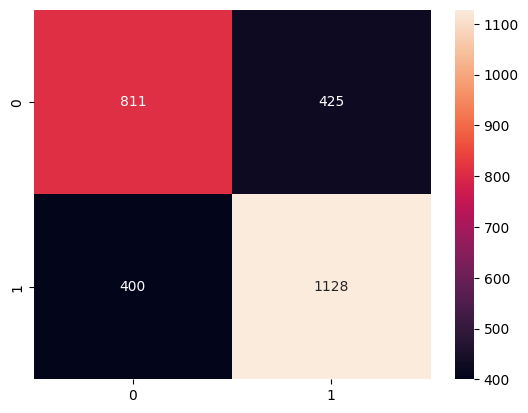

In [ ]:
sns.heatmap(confusion_matrix(y_test, prediction), annot = True, fmt='0.0f')

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lgr = LogisticRegression(random_state=0)
lgr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(random_state=0)

In [ ]:
y_pre_test = lgr.predict(X_test)
y_pre_train = lgr.predict(X_train)

In [ ]:
from sklearn.metrics import accuracy_score
train_accurry = accuracy_score(y_pre_train, y_train)
test_accurry = accuracy_score(y_pre_test, y_test)
print('Accuracy for train dataset for logistic reg : ', train_accurry)
print('Accuracy for test dataset for logistic reg : ', test_accurry)

Accuracy for train dataset for logistic reg :  0.9272705343143167
Accuracy for test dataset for logistic reg :  0.9218523878437048


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pre_test ))

              precision    recall  f1-score   support

          -1       0.93      0.89      0.91      1236
           1       0.91      0.95      0.93      1528

    accuracy                           0.92      2764
   macro avg       0.92      0.92      0.92      2764
weighted avg       0.92      0.92      0.92      2764



In [ ]:
confusion_matrix(y_test, y_pre_test )

array([[1098,  138],
       [  78, 1450]])

<Axes: >

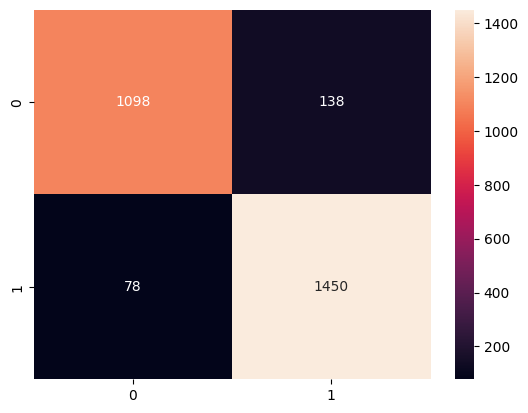

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pre_test), annot = True, fmt='0.0f')

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, CategoricalNB, BernoulliNB, ComplementNB

In [ ]:
# Bernoullis Navaive bayes classifier
nvb = BernoulliNB()
nvb.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


BernoulliNB()

In [ ]:
y_pre_test = nvb.predict(X_test)
y_pre_train = nvb.predict(X_train)

In [ ]:
from sklearn.metrics import accuracy_score
train_accurry = accuracy_score(y_pre_train, y_train)
test_accurry = accuracy_score(y_pre_test, y_test)
print('Accuracy for train dataset for naive bayes  reg : ', train_accurry)
print('Accuracy for test dataset for naive bayes reg : ', test_accurry)

Accuracy for train dataset for naive bayes  reg :  0.911590881678929
Accuracy for test dataset for naive bayes reg :  0.9059334298118669


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pre_test ))

              precision    recall  f1-score   support

          -1       0.90      0.89      0.89      1236
           1       0.91      0.92      0.92      1528

    accuracy                           0.91      2764
   macro avg       0.91      0.90      0.90      2764
weighted avg       0.91      0.91      0.91      2764



In [ ]:
confusion_matrix(y_test, y_pre_test)

array([[1096,  140],
       [ 120, 1408]])

<Axes: >

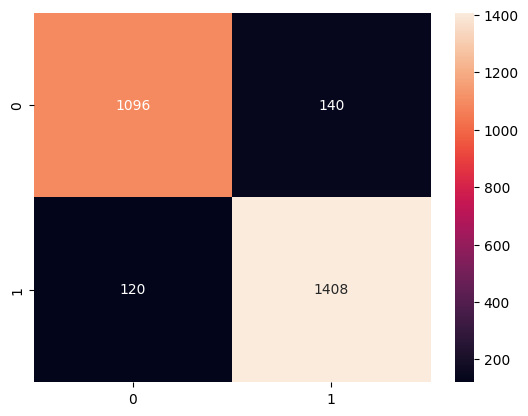

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pre_test), annot = True, fmt='0.0f')